In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Load processed data
# ------------------------------------------------------------

fact = pd.read_parquet(
    PROCESSED_DIR / "fact.parquet"
)

sales_daily = pd.read_parquet(
    PROCESSED_DIR / "sales_daily.parquet"
)

sku_master = pd.read_parquet(
    PROCESSED_DIR / "sku_master.parquet"
)

inventory = pd.read_parquet(
    PROCESSED_DIR / "inventory_latest.parquet"
)

calendar = pd.read_parquet(
    PROCESSED_DIR / "calendar.parquet"
)


# ------------------------------------------------------------
# Basic date preparation
# ------------------------------------------------------------

fact["date"] = pd.to_datetime(fact["date"])
sales_daily["date"] = pd.to_datetime(sales_daily["date"])

fact["year"] = fact["date"].dt.year
fact["month"] = fact["date"].dt.month
fact["month_name"] = fact["date"].dt.month_name()
fact["day_of_week"] = fact["date"].dt.day_name()


print("Data loaded successfully.")

print(f"Fact table shape: {fact.shape}")
print(f"Sales daily shape: {sales_daily.shape}")
print(f"SKU master shape: {sku_master.shape}")
print(f"Inventory shape: {inventory.shape}")

Data loaded successfully.
Fact table shape: (4143430, 28)
Sales daily shape: (4143430, 7)
SKU master shape: (5000, 7)
Inventory shape: (4495, 5)


## 1. Data Quality Assessment

Before performing exploratory analysis, we assess the completeness, consistency, uniqueness, and temporal coverage of the processed dataset.

In [2]:
# ============================================================
# DATA QUALITY SUMMARY
# ============================================================

quality_summary = pd.DataFrame({
    "Metric": [
        "Fact table rows",
        "Unique SKUs",
        "Date range start",
        "Date range end",
        "Duplicate date-SKU records",
        "Negative units sold",
        "Negative revenue",
        "SKUs missing inventory",
        "Fact rows missing inventory",
        "SKUs missing category",
    ],
    "Value": [
        len(fact),
        fact["sku_id"].nunique(),
        fact["date"].min().date(),
        fact["date"].max().date(),
        fact.duplicated(["date", "sku_id"]).sum(),
        (fact["units_sold"] < 0).sum(),
        (fact["revenue"] < 0).sum(),
        fact.loc[
            fact["inventory_data_available"] == 0,
            "sku_id"
        ].nunique(),
        (fact["inventory_data_available"] == 0).sum(),
        fact["category"].isna().sum(),
    ]
})

quality_summary

,Metric,Value
0,Fact table rows,4143430
1,Unique SKUs,5000
2,Date range start,2022-01-01
3,Date range end,2025-12-31
4,Duplicate date-SKU records,0
5,Negative units sold,0
6,Negative revenue,0
7,SKUs missing inventory,505
8,Fact rows missing inventory,417352
9,SKUs missing category,0


## 2. Missing Value Profile

Missing values are reviewed separately from valid zero values. In particular, unavailable inventory records are preserved as missing rather than interpreted as zero stock.

In [3]:
# Missing values in the main analysis table

missing = (
    fact.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    missing / len(fact) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Rows": missing,
    "Missing %": missing_pct
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Rows"] > 0
    ]
)

missing_summary

,Missing Rows,Missing %
inventory_above_reorder_point,417352,10.07
reorder_point,417352,10.07
safety_stock,417352,10.07
on_order_units,417352,10.07
on_hand_units,417352,10.07


## 3. Overall Demand Trend

We examine how total unit demand and revenue evolved over the four-year observation period.

In [4]:
# Aggregate daily demand

daily_demand = (
    fact.groupby("date", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

daily_demand.head()

,date,units_sold,revenue
0,2022-01-01,9539,5803048.93
1,2022-01-02,9645,5933508.44
2,2022-01-03,9696,6041608.01
3,2022-01-04,9755,5847850.64
4,2022-01-05,9322,5832333.56


In [5]:
# Aggregate daily demand

daily_demand = (
    fact.groupby("date", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

daily_demand.head()

,date,units_sold,revenue
0,2022-01-01,9539,5803048.93
1,2022-01-02,9645,5933508.44
2,2022-01-03,9696,6041608.01
3,2022-01-04,9755,5847850.64
4,2022-01-05,9322,5832333.56


In [6]:
monthly_demand = (
    fact.assign(
        month_start=fact["date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("month_start", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

monthly_demand.head()

,month_start,units_sold,revenue
0,2022-01-01,299649,1.820395e+08
1,2022-02-01,279983,1.710435e+08
2,2022-03-01,332417,2.042833e+08
3,2022-04-01,330560,2.050013e+08
4,2022-05-01,351452,2.063285e+08


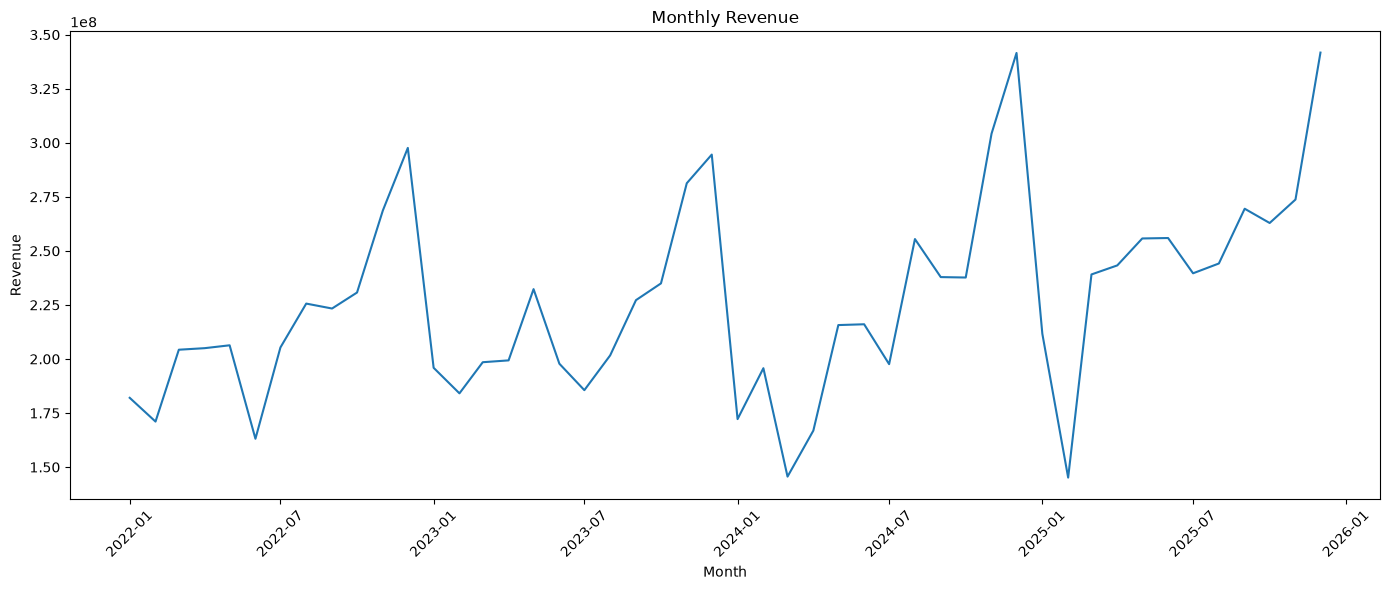

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand["month_start"],
    monthly_demand["revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
yearly_demand = (
    fact.groupby("year", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

yearly_demand["units_growth_pct"] = (
    yearly_demand["units_sold"]
    .pct_change() * 100
)

yearly_demand["revenue_growth_pct"] = (
    yearly_demand["revenue"]
    .pct_change() * 100
)

yearly_demand

,year,units_sold,revenue,units_growth_pct,revenue_growth_pct
0,2022,4311184,2.583127e+09,NaN,NaN
1,2023,4573873,2.633266e+09,6.093199,1.941007
2,2024,4830755,2.686557e+09,5.616291,2.023778
3,2025,4985094,2.982529e+09,3.194925,11.016773


In [9]:
monthly_seasonality = (
    fact.groupby("month", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

monthly_seasonality["month_name"] = (
    pd.to_datetime(
        monthly_seasonality["month"],
        format="%m"
    ).dt.month_name()
)

monthly_seasonality

,month,units_sold,revenue,month_name
0,1,1302295,7.617881e+08,January
1,2,1224500,6.960210e+08,February
2,3,1447920,7.874847e+08,March
3,4,1449934,8.145107e+08,April
4,5,1528720,9.100694e+08,May
5,6,1532841,8.329134e+08,June
6,7,1449940,8.281438e+08,July
7,8,1604827,9.269279e+08,August
8,9,1608688,9.579354e+08,September
9,10,1598932,9.662804e+08,October


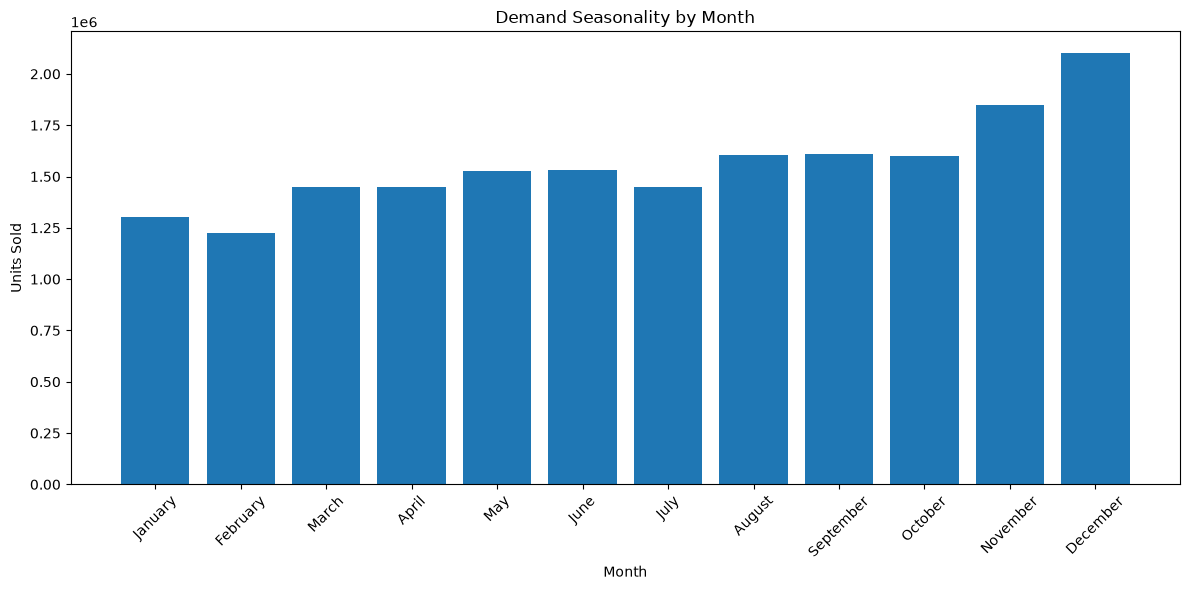

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_seasonality["month_name"],
    monthly_seasonality["units_sold"]
)

plt.title("Demand Seasonality by Month")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = (
    fact.groupby("day_of_week", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

weekday_demand["day_of_week"] = pd.Categorical(
    weekday_demand["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_demand = weekday_demand.sort_values(
    "day_of_week"
)

weekday_demand

,day_of_week,units_sold,revenue
1,Monday,2675444,1.555179e+09
5,Tuesday,2680105,1.557900e+09
6,Wednesday,2676119,1.562068e+09
4,Thursday,2656842,1.553493e+09
0,Friday,2663805,1.549439e+09
2,Saturday,2679112,1.559651e+09
3,Sunday,2669479,1.547750e+09


In [12]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = (
    fact.groupby("day_of_week", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

weekday_demand["day_of_week"] = pd.Categorical(
    weekday_demand["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_demand = weekday_demand.sort_values(
    "day_of_week"
)

weekday_demand

,day_of_week,units_sold,revenue
1,Monday,2675444,1.555179e+09
5,Tuesday,2680105,1.557900e+09
6,Wednesday,2676119,1.562068e+09
4,Thursday,2656842,1.553493e+09
0,Friday,2663805,1.549439e+09
2,Saturday,2679112,1.559651e+09
3,Sunday,2669479,1.547750e+09


In [13]:
sku_performance = (
    fact.groupby("sku_id", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        active_days=("date", "nunique")
    )
)

sku_performance = sku_performance.merge(
    sku_master[
        [
            "sku_id",
            "sku_name",
            "category",
            "subcategory",
            "brand"
        ]
    ],
    on="sku_id",
    how="left"
)

sku_performance.head()

,sku_id,units_sold,revenue,active_days,sku_name,category,subcategory,brand
0,SKU00001,4771,3624393.59,1207,NutriPlus Cookware Large,Home & Kitchen,Cookware,NutriPlus
1,SKU00002,38167,2518160.08,1461,CrispKing Bread Family Pack,Dairy & Bakery,Bread,CrispKing
2,SKU00003,1325,189058.31,570,SoftTouch Notebooks 2L,Stationery & Office,Notebooks,SoftTouch
3,SKU00004,2534,556401.40,901,SunriseFoods Eggs Large,Dairy & Bakery,Eggs,SunriseFoods
4,SKU00005,2292,300920.55,821,SunriseFoods Pest Control Pack of 6,Home Care,Pest Control,SunriseFoods


In [14]:
sku_performance = (
    fact.groupby("sku_id", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        active_days=("date", "nunique")
    )
)

sku_performance = sku_performance.merge(
    sku_master[
        [
            "sku_id",
            "sku_name",
            "category",
            "subcategory",
            "brand"
        ]
    ],
    on="sku_id",
    how="left"
)

sku_performance.head()

,sku_id,units_sold,revenue,active_days,sku_name,category,subcategory,brand
0,SKU00001,4771,3624393.59,1207,NutriPlus Cookware Large,Home & Kitchen,Cookware,NutriPlus
1,SKU00002,38167,2518160.08,1461,CrispKing Bread Family Pack,Dairy & Bakery,Bread,CrispKing
2,SKU00003,1325,189058.31,570,SoftTouch Notebooks 2L,Stationery & Office,Notebooks,SoftTouch
3,SKU00004,2534,556401.40,901,SunriseFoods Eggs Large,Dairy & Bakery,Eggs,SunriseFoods
4,SKU00005,2292,300920.55,821,SunriseFoods Pest Control Pack of 6,Home Care,Pest Control,SunriseFoods


In [15]:
top_revenue = (
    sku_performance
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_revenue[
    [
        "sku_id",
        "sku_name",
        "category",
        "units_sold",
        "revenue"
    ]
]

,sku_id,sku_name,category,units_sold,revenue
4320,SKU04321,EliteHome Hair Care Pack of 6,Personal Care,1186104,1.069036e+09
3726,SKU03727,QuickBite Mobile Accessories 2kg,Electronics & Accessories,166840,2.599450e+08
4328,SKU04329,SoftTouch Cookware 2kg,Home & Kitchen,41153,9.419997e+07
4595,SKU04596,ValueChoice Eggs Pack of 6,Dairy & Bakery,283431,8.881353e+07
3052,SKU03053,PremiumSelect Kids Wear Family Pack,Apparel & Footwear,21787,8.354538e+07
1370,SKU01371,PureLife Cookware 1L,Home & Kitchen,69864,8.312455e+07
1188,SKU01189,PureLife Footwear 500g,Apparel & Footwear,32183,6.942638e+07
4550,SKU04551,DailyBest Cookware Small,Home & Kitchen,29679,6.879118e+07
4156,SKU04157,PremiumSelect Small Appliances 1L,Electronics & Accessories,27308,6.873643e+07
4570,SKU04571,EliteHome Ready Meals 250g,Frozen Foods,75939,6.218228e+07


In [18]:
category_performance = (
    fact.groupby("category", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        sku_count=("sku_id", "nunique")
    )
    .sort_values(
        "revenue",
        ascending=False
    )
)

category_performance

,category,units_sold,revenue,sku_count
3,Electronics & Accessories,1378400,2.328292e+09,394
0,Apparel & Footwear,1224134,1.911954e+09,410
9,Personal Care,2704996,1.618258e+09,410
7,Home & Kitchen,1402335,1.578784e+09,390
6,Health & Wellness,1255311,8.889558e+08,396
4,Frozen Foods,1548577,8.136173e+08,422
8,Home Care,1553994,4.220981e+08,425
2,Dairy & Bakery,1718591,3.511117e+08,428
5,Grocery,1491246,3.493301e+08,395
11,Stationery & Office,1742469,3.093953e+08,459


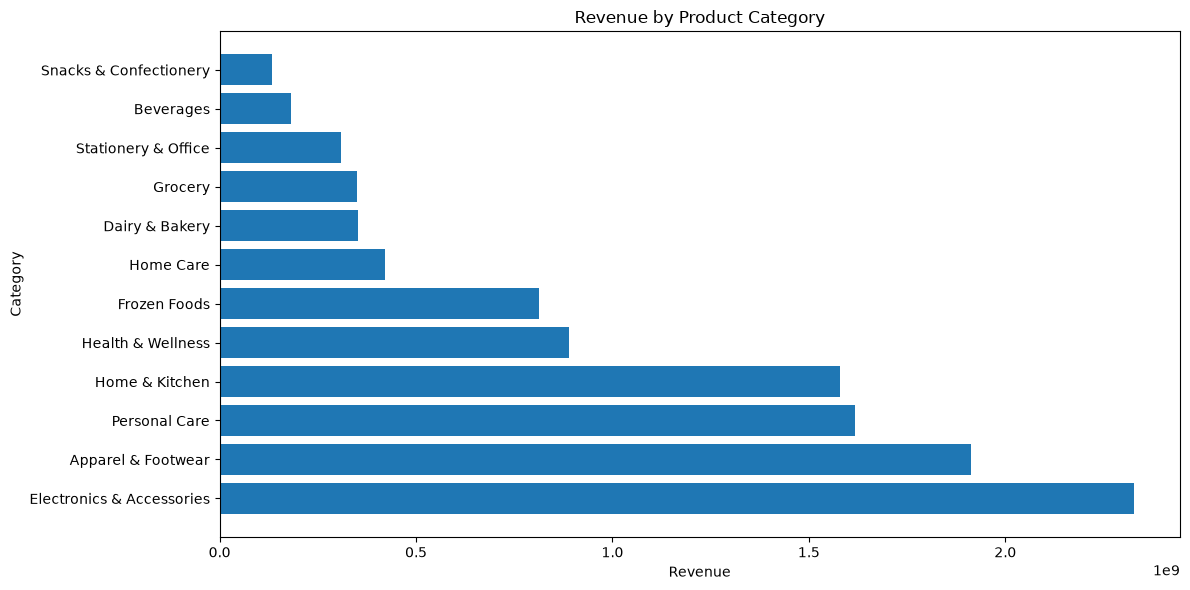

In [19]:
plt.figure(figsize=(12, 6))

plt.barh(
    category_performance["category"],
    category_performance["revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [20]:
sku_demand = (
    fact.groupby("sku_id", as_index=False)
    .agg(
        total_units=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        active_days=("date", "nunique")
    )
)

sku_demand["avg_daily_units"] = (
    sku_demand["total_units"]
    / sku_demand["active_days"]
)

sku_demand.describe()

,total_units,total_revenue,active_days,avg_daily_units
count,5.000000e+03,5.000000e+03,5000.000000,5000.000000
mean,3.740181e+03,2.177096e+06,828.686000,3.716835
std,1.833729e+04,1.618962e+07,269.346003,12.456890
min,1.105000e+03,3.302122e+04,473.000000,2.166667
25%,1.494000e+03,3.251242e+05,611.000000,2.454914
50%,1.969000e+03,7.171632e+05,744.000000,2.656463
75%,3.157500e+03,1.970291e+06,990.000000,3.190190
max,1.186104e+06,1.069036e+09,1461.000000,811.843943


In [21]:
sku_demand[
    [
        "total_units",
        "avg_daily_units",
        "active_days"
    ]
].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50]
)

,total_units,avg_daily_units,active_days
0.01,1186.00,2.264803,512.0
0.05,1261.95,2.330458,535.0
0.10,1316.00,2.369195,555.0
0.25,1494.00,2.454914,611.0
0.50,1969.00,2.656463,744.0


## 8. Demand Concentration and Extreme Movers

The SKU-level demand distribution is highly skewed. We investigate the highest-volume SKU separately to determine whether the concentration reflects a genuine demand pattern or an injected dataset condition.

In [22]:
extreme_sku = (
    sku_performance
    .sort_values("units_sold", ascending=False)
    .head(20)
)

extreme_sku[
    [
        "sku_id",
        "sku_name",
        "category",
        "units_sold",
        "revenue",
        "active_days"
    ]
]

,sku_id,sku_name,category,units_sold,revenue,active_days
4320,SKU04321,EliteHome Hair Care Pack of 6,Personal Care,1186104,1.069036e+09,1461
4595,SKU04596,ValueChoice Eggs Pack of 6,Dairy & Bakery,283431,8.881353e+07,1461
3726,SKU03727,QuickBite Mobile Accessories 2kg,Electronics & Accessories,166840,2.599450e+08,1461
4153,SKU04154,TrueTaste Spices & Seasoning Medium,Grocery,131174,4.259141e+07,1461
952,SKU00953,CityFresh Writing Instruments 250ml,Stationery & Office,114297,2.935862e+07,1461
189,SKU00190,ZestyCo Writing Instruments 1L,Stationery & Office,101824,1.388548e+07,1461
2140,SKU02141,PureLife Bath & Body Family Pack,Personal Care,98951,4.392344e+07,1461
993,SKU00994,NovaFresh Home Decor 2L,Home & Kitchen,95420,5.351277e+07,1461
3291,SKU03292,SoftTouch Pulses & Lentils Family Pack,Grocery,92494,1.409103e+07,1461
1774,SKU01775,CityFresh Hair Care 2L,Personal Care,80414,1.545274e+07,1461


In [24]:
flags = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "sku_inventory_flags.csv"
)

flags.head()

,sku_id,flag,affected_stores,window_start,window_end,notes
0,SKU04321,STOCKOUT_RISK,ST22;ST26;ST23;ST15;ST12;ST28;ST01;ST27;ST08;S...,2025-11-06,2025-12-03,Top-selling SKU (by observed volume); injected...
1,SKU04596,STOCKOUT_RISK,ST12;ST09;ST21;ST23;ST07;ST24;ST01;ST28;ST14;S...,2025-10-25,2025-11-06,Top-selling SKU (by observed volume); injected...
2,SKU03727,STOCKOUT_RISK,ST19;ST14;ST28;ST29;ST02;ST07;ST17;ST08;ST05;ST16,2025-11-08,2025-11-29,Top-selling SKU (by observed volume); injected...
3,SKU04154,STOCKOUT_RISK,ST15;ST03;ST30;ST09;ST24;ST19;ST28;ST02;ST07;S...,2025-11-12,2025-11-26,Top-selling SKU (by observed volume); injected...
4,SKU00953,STOCKOUT_RISK,ST09;ST19;ST27;ST20;ST01;ST03;ST11;ST10;ST22;S...,2025-11-29,2025-12-25,Top-selling SKU (by observed volume); injected...


In [25]:
flags["flag"].value_counts()

flag
SLOW_MOVER       400
STOCKOUT_RISK    200
Name: count, dtype: int64

In [26]:
flag_summary = (
    flags.groupby("flag")
    .agg(
        sku_count=("sku_id", "nunique")
    )
    .reset_index()
)

flag_summary

,flag,sku_count
0,SLOW_MOVER,400
1,STOCKOUT_RISK,200


In [27]:
flagged_sku_analysis = flags.merge(
    sku_performance,
    on="sku_id",
    how="left"
)

flagged_sku_analysis[
    [
        "sku_id",
        "flag",
        "sku_name",
        "category",
        "units_sold",
        "revenue",
        "active_days"
    ]
].sort_values(
    "units_sold",
    ascending=False
).head(20)

,sku_id,flag,sku_name,category,units_sold,revenue,active_days
0,SKU04321,STOCKOUT_RISK,EliteHome Hair Care Pack of 6,Personal Care,1186104,1.069036e+09,1461
1,SKU04596,STOCKOUT_RISK,ValueChoice Eggs Pack of 6,Dairy & Bakery,283431,8.881353e+07,1461
2,SKU03727,STOCKOUT_RISK,QuickBite Mobile Accessories 2kg,Electronics & Accessories,166840,2.599450e+08,1461
3,SKU04154,STOCKOUT_RISK,TrueTaste Spices & Seasoning Medium,Grocery,131174,4.259141e+07,1461
4,SKU00953,STOCKOUT_RISK,CityFresh Writing Instruments 250ml,Stationery & Office,114297,2.935862e+07,1461
5,SKU00190,STOCKOUT_RISK,ZestyCo Writing Instruments 1L,Stationery & Office,101824,1.388548e+07,1461
6,SKU02141,STOCKOUT_RISK,PureLife Bath & Body Family Pack,Personal Care,98951,4.392344e+07,1461
7,SKU00994,STOCKOUT_RISK,NovaFresh Home Decor 2L,Home & Kitchen,95420,5.351277e+07,1461
8,SKU03292,STOCKOUT_RISK,SoftTouch Pulses & Lentils Family Pack,Grocery,92494,1.409103e+07,1461
9,SKU01775,STOCKOUT_RISK,CityFresh Hair Care 2L,Personal Care,80414,1.545274e+07,1461


In [34]:
inventory_analysis = (
    inventory.merge(
        sku_master[
            [
                "sku_id",
                "sku_name",
                "category",
                "cost_price"
            ]
        ],
        on="sku_id",
        how="left"
    )
)

inventory_analysis.head()

,sku_id,on_hand_units,reorder_point,safety_stock,on_order_units,sku_name,category,cost_price
0,SKU00001,215,100,33,0,NutriPlus Cookware Large,Home & Kitchen,619.77
1,SKU00002,0,1582,573,0,CrispKing Bread Family Pack,Dairy & Bakery,49.57
2,SKU00003,414,250,85,0,SoftTouch Notebooks 2L,Stationery & Office,83.67
3,SKU00004,148,99,35,0,SunriseFoods Eggs Large,Dairy & Bakery,156.32
4,SKU00005,411,284,104,0,SunriseFoods Pest Control Pack of 6,Home Care,83.46


In [38]:
inventory_analysis["inventory_value"] = (
    inventory_analysis["on_hand_units"]
    * inventory_analysis["cost_price"]
)

inventory_analysis[
    [
        "on_hand_units",
        "reorder_point",
        "safety_stock",
        "inventory_value"
    ]
].describe()

,on_hand_units,reorder_point,safety_stock,inventory_value
count,4495.000000,4495.000000,4495.000000,4.495000e+03
mean,976.395773,352.400222,123.090768,4.113974e+05
std,2197.970332,508.620311,177.892882,1.517726e+06
min,0.000000,20.000000,5.000000,0.000000e+00
25%,94.000000,83.000000,28.000000,1.484268e+04
50%,198.000000,147.000000,50.000000,4.400493e+04
75%,361.000000,245.500000,88.000000,1.525129e+05
max,10515.000000,2181.000000,768.000000,2.421189e+07


In [39]:
inventory_analysis["below_reorder_point"] = (
    inventory_analysis["on_hand_units"]
    < inventory_analysis["reorder_point"]
)

In [40]:
reorder_summary = pd.DataFrame({
    "Metric": [
        "Total inventory records",
        "Below reorder point",
        "At/above reorder point",
        "Below reorder percentage"
    ],
    "Value": [
        len(inventory_analysis),
        inventory_analysis["below_reorder_point"].sum(),
        (~inventory_analysis["below_reorder_point"]).sum(),
        round(
            inventory_analysis["below_reorder_point"].mean() * 100,
            2
        )
    ]
})

reorder_summary

,Metric,Value
0,Total inventory records,4495.00
1,Below reorder point,1105.00
2,At/above reorder point,3390.00
3,Below reorder percentage,24.58


In [41]:
risk = pd.read_parquet(
    PROCESSED_DIR / "risk_scoring.parquet"
)

risk[
    [
        "sku_id",
        "sku_name",
        "risk",
        "forecast_weekly_demand",
        "inventory_position",
        "weeks_of_cover",
        "reorder_point",
        "safety_stock",
        "stockout_exposure",
        "excess_inventory_value",
    ]
].sort_values(
    "weeks_of_cover",
    ascending=False
).head(20)

,sku_id,sku_name,risk,forecast_weekly_demand,inventory_position,weeks_of_cover,reorder_point,safety_stock,stockout_exposure,excess_inventory_value
2717,SKU02718,SmartBuy Soft Drinks Family Pack,OVERSTOCK,3.793153,7986.0,2105.372654,1737.0,632.0,0.0,8.052927e+05
3114,SKU03115,NutriPlus Frozen Vegetables 100g,OVERSTOCK,5.951690,10515.0,1766.725100,2171.0,768.0,0.0,6.098531e+06
3931,SKU03932,QuickBite Milk Family Pack,OVERSTOCK,5.221105,9179.0,1758.056963,1910.0,673.0,0.0,9.810173e+05
4986,SKU04987,GreenValley Dishwashing 500g,OVERSTOCK,4.940610,8540.0,1728.531605,1975.0,716.0,0.0,2.673225e+06
3280,SKU03281,SoftTouch Chips & Crisps Small,OVERSTOCK,6.099729,10211.0,1674.008669,2181.0,760.0,0.0,9.868779e+05
1821,SKU01822,CleanWave Office Supplies Medium,OVERSTOCK,5.357306,8786.0,1640.003503,1891.0,706.0,0.0,9.236981e+05
4504,SKU04505,SoftTouch Energy Drinks 500ml,OVERSTOCK,5.412587,8730.0,1612.907158,1886.0,699.0,0.0,7.039830e+05
4474,SKU04475,GreenValley Men's Grooming Pack of 12,OVERSTOCK,6.054625,9740.0,1608.687539,2147.0,746.0,0.0,8.733516e+05
4413,SKU04414,DailyBest Candy 1L,OVERSTOCK,5.678176,9126.0,1607.206384,1888.0,666.0,0.0,1.070911e+06
1173,SKU01174,NovaFresh Home Decor 2L,OVERSTOCK,5.638097,9037.0,1602.845673,1898.0,613.0,0.0,1.318660e+07


In [42]:
risk[
    "weeks_of_cover"
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    5000.000000
mean      129.903601
std       343.530448
min         0.000000
25%         4.064037
50%        13.768583
75%        31.735871
90%       661.894344
95%      1139.389581
99%      1422.806759
max      2105.372654
Name: weeks_of_cover, dtype: float64

In [43]:
risk.groupby("risk").agg(
    sku_count=("sku_id", "nunique"),
    avg_forecast=("forecast_weekly_demand", "mean"),
    avg_inventory=("inventory_position", "mean"),
    avg_weeks_cover=("weeks_of_cover", "mean"),
    stockout_exposure=("stockout_exposure", "sum"),
    excess_inventory_value=("excess_inventory_value", "sum")
).sort_values(
    "sku_count",
    ascending=False
)

,sku_count,avg_forecast,avg_inventory,avg_weeks_cover,stockout_exposure,excess_inventory_value
risk,,,,,,
OVERSTOCK,2500,9.922917,1672.596400,254.346915,0.000000e+00,1.722377e+09
HEALTHY,888,21.249303,139.015766,7.185741,0.000000e+00,0.000000e+00
WATCH,813,15.862921,96.944649,8.828344,0.000000e+00,0.000000e+00
NO INVENTORY DATA,505,13.696935,0.000000,0.000000,0.000000e+00,0.000000e+00
STOCKOUT RISK,294,102.187489,17.503401,0.314057,5.242731e+07,0.000000e+00


In [44]:
flags = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "sku_inventory_flags.csv"
)

flagged_risk = flags[
    ["sku_id", "flag"]
].merge(
    risk[
        [
            "sku_id",
            "risk",
            "weeks_of_cover",
            "forecast_weekly_demand",
            "inventory_position"
        ]
    ],
    on="sku_id",
    how="left"
)

pd.crosstab(
    flagged_risk["flag"],
    flagged_risk["risk"]
)

risk,OVERSTOCK,STOCKOUT RISK,WATCH
flag,,,
SLOW_MOVER,400,0,0
STOCKOUT_RISK,0,157,43


In [45]:
flagged_risk.groupby("flag").agg(
    sku_count=("sku_id", "nunique"),
    avg_forecast=("forecast_weekly_demand", "mean"),
    avg_inventory=("inventory_position", "mean"),
    avg_weeks_cover=("weeks_of_cover", "mean")
)

,sku_count,avg_forecast,avg_inventory,avg_weeks_cover
flag,,,,
SLOW_MOVER,400,6.256981,7164.355,1156.876506
STOCKOUT_RISK,200,151.400571,55.100,0.665005
